# LDA with gensim and spaCy

## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/DataScience/headlines-topic-modeling/LDA Models/'

Mounted at /content/drive


In [2]:
!pip install -qq gensim
!pip install pyLDAvis -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 8.7 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd

#sklearn
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

#Gensim
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel
from gensim.models import Phrases
from gensim.models.phrases import Phraser

#spacy
import spacy
from nltk.corpus import stopwords

#vis
import pyLDAvis
import pyLDAvis.gensim
import matplotlib.pyplot as plt

#pickle
import pickle

#warnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Preparing the data

In [ ]:
pd.set_option('display.max_colwidth', None)
headlines = pd.read_csv('/content/abcnews-date-text.csv')
headlines

,publish_date,headline_text
0,20030219,aba decides against community broadcasting licence
1,20030219,act fire witnesses must be aware of defamation
2,20030219,a g calls for infrastructure protection summit
3,20030219,air nz staff in aust strike for pay rise
4,20030219,air nz strike to affect australian travellers
...,...,...
1244179,20211231,two aged care residents die as state records 2;093
1244180,20211231,victoria records 5;919 new cases and seven deaths
1244181,20211231,wa delays adopting new close contact definition
1244182,20211231,western ringtail possums found badly dehydrated in heatwave


In [ ]:
headlines['year'] = headlines['publish_date'] // 10000
headlines['month'] = (headlines['publish_date'] // 100) % 100
headlines['months_since_2003'] = (headlines['year'] - 2003) * 12 + headlines['month']
headlines = headlines.drop(['year', 'month'], axis=1)
headlines

,publish_date,headline_text,months_since_2003
0,20030219,aba decides against community broadcasting licence,2
1,20030219,act fire witnesses must be aware of defamation,2
2,20030219,a g calls for infrastructure protection summit,2
3,20030219,air nz staff in aust strike for pay rise,2
4,20030219,air nz strike to affect australian travellers,2
...,...,...,...
1244179,20211231,two aged care residents die as state records 2;093,228
1244180,20211231,victoria records 5;919 new cases and seven deaths,228
1244181,20211231,wa delays adopting new close contact definition,228
1244182,20211231,western ringtail possums found badly dehydrated in heatwave,228


In [ ]:
X_train, X_test = train_test_split(headlines, train_size=100000, random_state=111, stratify=headlines['months_since_2003'])
X_train = X_train.reset_index()
X_train = X_train.drop('index', axis=1)
X_train

,publish_date,headline_text,months_since_2003
0,20170908,turnbull promises to step up australias engagement in pacific,177
1,20071220,police appeal for safe driving over holiday period,60
2,20060720,fast food worker not put off by shooting,43
3,20111013,readfearn carbon price pulls through anti climate change furor,106
4,20130415,brenton kroen from waikerie,124
...,...,...,...
99995,20190317,tasmanian aboriginal food business spreading culture,195
99996,20101226,sydney to hobart start review,96
99997,20091111,treasurer kevin foley tells 891 of 10m,83
99998,20100113,bumper tourism season,85


## Text preprocessing w/ bigrams and trigrams

In [ ]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def lemmatization(texts, allowed_postags=["NOUN", "ADJ", "VERB", "ADV"]):
    texts_out = []

    for doc in nlp.pipe(texts, batch_size=2000, n_process=-1):

        new_text = [t.lemma_ for t in doc if t.pos_ in allowed_postags
                    and not t.is_stop and len(t.lemma_) > 2 and t.is_alpha]
        texts_out.append(new_text)

    return texts_out

In [ ]:
data_tokens = lemmatization(X_train['headline_text'])
print(data_tokens[0][0:20])

['turnbull', 'promise', 'step', 'australias', 'engagement']


In [ ]:
bigram = Phrases(data_tokens, min_count=5, threshold=100)
trigram = Phrases(bigram[data_tokens], threshold=100)

bigram_mod = Phraser(bigram)
trigram_mod = Phraser(trigram)

clean_docs = [trigram_mod[bigram_mod[doc]] for doc in data_tokens]

with open(f'{folder_path}clean_docs.pkl', 'wb') as f:
    pickle.dump(clean_docs, f)

## Determining optimal # of topics

### Creating new dictionary

In [ ]:
id2word = corpora.Dictionary(clean_docs)
id2word.filter_extremes(no_below=10, no_above=.4, keep_n=100000)
corpus = [id2word.doc2bow(text) for text in clean_docs]

In [ ]:
id2word.save(f'{folder_path}/headlines_dictionary.dict')

### Using saved dictionary

In [6]:
id2word = corpora.Dictionary.load('/content/drive/MyDrive/DataScience/headlines-topic-modeling/LDA Models/headlines_dictionary.dict')

with open(f'{folder_path}clean_docs.pkl', 'rb') as f:
    clean_docs = pickle.load(f)

corpus = [id2word.doc2bow(text) for text in clean_docs]

### Testing k

In [ ]:
topic_range = np.arange(20, 201, 10)
c_measures = ['c_v', 'u_mass', 'c_uci', 'c_npmi']
c_vals = {c_measure: [] for c_measure in c_measures}

for k in topic_range:
  print(f"Testing K={k}...")

  lda_topic_range = gensim.models.LdaModel(
                    corpus=corpus,
                    id2word=id2word,
                    num_topics=k,
                    random_state = 111,
                    update_every=1,
                    chunksize=10000,
                    passes=5,
                    alpha='auto',
                    eta='auto'
                    )

  for m in c_measures:
    if m == 'u_mass':
        cm = CoherenceModel(model=lda_topic_range, corpus=corpus, dictionary=id2word, coherence=m)
    else:
        cm = CoherenceModel(model=lda_topic_range, texts=clean_docs, dictionary=id2word, coherence=m)

    c_vals[m].append(cm.get_coherence())

Testing K=20...
Testing K=30...
Testing K=40...
Testing K=50...
Testing K=60...
Testing K=70...
Testing K=80...
Testing K=90...
Testing K=100...
Testing K=110...
Testing K=120...
Testing K=130...
Testing K=140...
Testing K=150...
Testing K=160...
Testing K=170...
Testing K=180...
Testing K=190...
Testing K=200...


## Visualizing the coherence scores

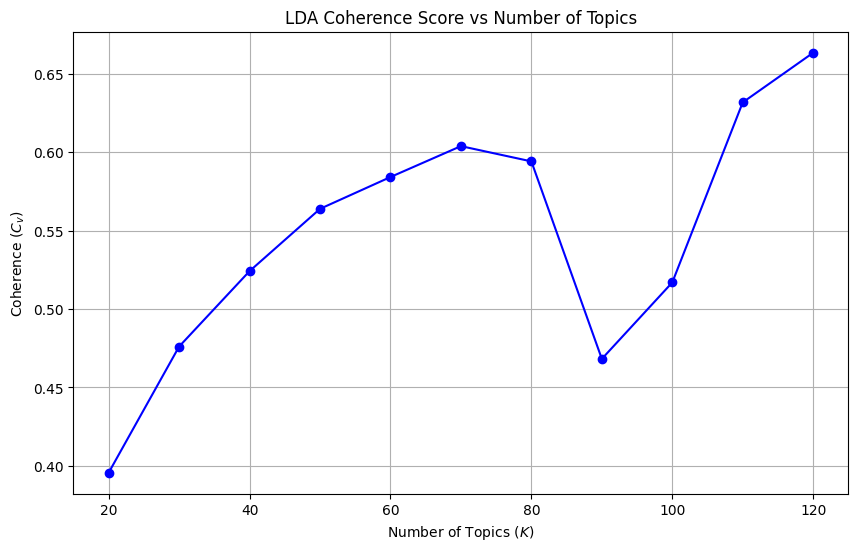

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(topic_range, c_vals, marker='o', color='b', linestyle='-')
plt.title("LDA Coherence Score vs Number of Topics")
plt.xlabel("Number of Topics ($K$)")
plt.ylabel("Coherence ($C_v$)")
plt.grid(True)
plt.show()

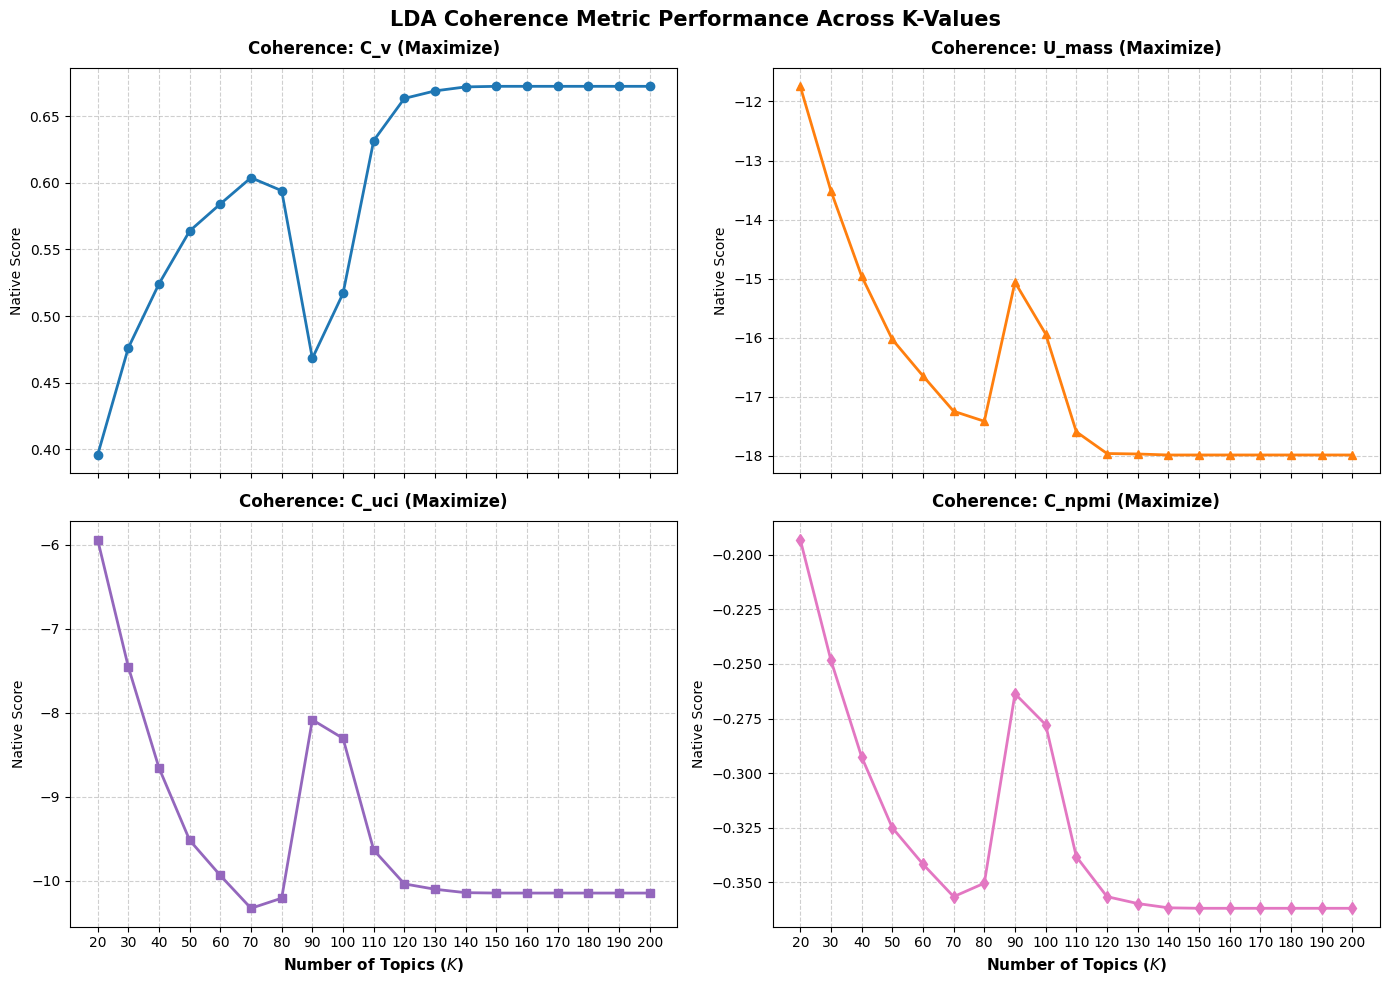

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

plot_configs = {
    'c_v':    {'idx': 0, 'title': 'Coherence: C_v (Maximize)',    'color': '#1f77b4', 'marker': 'o'},
    'u_mass': {'idx': 1, 'title': 'Coherence: U_mass (Maximize)', 'color': '#ff7f0e', 'marker': '^'},
    'c_uci':  {'idx': 2, 'title': 'Coherence: C_uci (Maximize)',  'color': '#9467bd', 'marker': 's'},
    'c_npmi':  {'idx': 3, 'title': 'Coherence: C_npmi (Maximize)',  'color': '#e377c2', 'marker': 'd'}
}

for measure, config in plot_configs.items():
    ax = axes[config['idx']]

    ax.plot(topic_range, c_vals[measure],
            marker=config['marker'],
            color=config['color'],
            linewidth=2,
            linestyle='-')

    ax.set_title(config['title'], fontsize=12, weight='bold', pad=10)
    ax.set_ylabel("Native Score", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)

    ax.set_xticks(topic_range)

axes[2].set_xlabel("Number of Topics ($K$)", fontsize=11, weight='bold')
axes[3].set_xlabel("Number of Topics ($K$)", fontsize=11, weight='bold')

plt.suptitle("LDA Coherence Metric Performance Across K-Values", fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Training the model

In [17]:
lda_30 = gensim.models.LdaModel(
          corpus=corpus,
          id2word=id2word,
          num_topics=30,
          random_state = 111,
          update_every=1,
          chunksize=10000,
          passes=20,
          alpha='auto',
          eta='auto'
          )

cm = CoherenceModel(model=lda_30, texts=clean_docs, dictionary=id2word, coherence='c_v')
print(cm.get_coherence())

0.4738388408672721


In [7]:
lda_120 = gensim.models.LdaModel(
          corpus=corpus,
          id2word=id2word,
          num_topics=120,
          random_state = 111,
          update_every=1,
          chunksize=10000,
          passes=20,
          alpha='auto',
          eta='auto'
          )

cm = CoherenceModel(model=lda_120, texts=clean_docs, dictionary=id2word, coherence='c_v')
print(cm.get_coherence())

0.6648437122111254


In [20]:
lda_30.save(f'{folder_path}/news_lda_30_model2.model')

In [19]:
lda_120.save(f'{folder_path}/news_lda_120_model.model')

In [22]:
lda_30_1 = gensim.models.LdaModel.load(f'{folder_path}/news_lda_model.model')

In [24]:
lda_70 = gensim.models.LdaModel.load(f'{folder_path}/news_lda_70_model.model')

## Visualizing the trained model

In [18]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_30, corpus, id2word, mds="mmds", R=30)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
11    -0.473082 -0.222066       1        1  6.358786
7      0.086888 -0.315017       2        1  4.667011
12    -0.480693 -0.029957       3        1  4.071628
19     0.363695 -0.274477       4        1  3.948805
4      0.467982 -0.195093       5        1  3.903923
24     0.513185  0.002615       6        1  3.785375
15     0.459161  0.213661       7        1  3.691843
25     0.151403 -0.470034       8        1  3.643046
8     -0.334140 -0.332844       9        1  3.618945
23    -0.240552 -0.431576      10        1  3.581406
10    -0.230318  0.024923      11        1  3.366828
3     -0.479433  0.144077      12        1  3.295414
20    -0.078226 -0.080453      13        1  3.171826
17    -0.105313 -0.384452      14        1  3.159434
5      0.047694  0.495963      15        1  3.158504
2     -0.176633  0.293451      16        1  3.139494
18    -0.395210  0.335308      17        1  3.031415
21    -0.334031 -0.157283      18        1  3.024216
29    -0.024536 -0.501926      19        1  2.943650
26     0.293308 -0.397374      20        1  2.938679
1      0.134081 -0.122283      21        1  2.918752
0      0.189955  0.455691      22        1  2.880879
13    -0.334094  0.167668      23        1  2.860447
9      0.053222  0.233174      24        1  2.838274
6     -0.229775  0.451597      25        1  2.788297
14    -0.068228  0.431500      26        1  2.766262
16     0.214565  0.031497      27        1  2.668010
22     0.388454  0.019028      28        1  2.650132
28     0.295408  0.231212      29        1  2.620444
27     0.325263  0.383472      30        1  2.508274, topic_info=            Term         Freq        Total Category  logprob  loglift
9         police  2868.000000  2868.000000  Default  30.0000  30.0000
135          man  2481.000000  2481.000000  Default  29.0000  29.0000
131          say  2025.000000  2025.000000  Default  28.0000  28.0000
98          plan  1832.000000  1832.000000  Default  27.0000  27.0000
39          fire  1605.000000  1605.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
1238    unlikely    73.564894    74.544637  Topic30  -4.8133   3.6723
1443  queensland    72.736678    73.716421  Topic30  -4.8246   3.6722
1000      easter    67.262049    68.241791  Topic30  -4.9028   3.6711
3720        rice    65.147779    66.127522  Topic30  -4.9348   3.6706
1471  evacuation    64.646412    65.626154  Topic30  -4.9425   3.6705

[997 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
1053     22  0.997578  aboriginal
445       6  0.997577       abuse
1952     13  0.995378      access
578       1  0.997563    accident
63        1  0.998469      accuse
...     ...       ...         ...
149      19  0.146013        year
250       5  0.996021       young
1114     17  0.994020       youth
1690      7  0.816904        zone
1690     28  0.171550        zone

[1077 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[12, 8, 13, 20, 5, 25, 16, 26, 9, 24, 11, 4, 21, 18, 6, 3, 19, 22, 30, 27, 2, 1, 14, 10, 7, 15, 17, 23, 29, 28])

In [23]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_30_1, corpus, id2word, mds="mmds", R=30)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
11     0.264053  0.060536       1        1  6.217197
7      0.508125  0.094644       2        1  4.466886
12    -0.247802  0.066940       3        1  4.084082
19    -0.456981 -0.241222       4        1  3.945826
4      0.065353 -0.345895       5        1  3.790003
15    -0.119401 -0.158961       6        1  3.778253
8     -0.293172 -0.203928       7        1  3.660117
24    -0.031982  0.105197       8        1  3.654560
23     0.014379  0.295215       9        1  3.579864
25     0.083669 -0.127138      10        1  3.555828
10     0.474727 -0.158877      11        1  3.369431
2     -0.040745  0.473489      12        1  3.203262
3      0.276967  0.243678      13        1  3.197871
20    -0.372299  0.362222      14        1  3.196260
17     0.117511  0.491618      15        1  3.177093
5     -0.258847  0.293991      16        1  3.135798
18    -0.465400  0.055450      17        1  3.077649
1     -0.445943  0.195539      18        1  3.009383
26     0.421527  0.050538      19        1  2.992088
29    -0.171999 -0.412531      20        1  2.985553
21     0.292116 -0.154982      21        1  2.925989
13     0.222977  0.401361      22        1  2.908140
0      0.404807  0.327094      23        1  2.884828
9     -0.478222 -0.079830      24        1  2.862718
14     0.257179 -0.382185      25        1  2.854253
6     -0.054488 -0.489511      26        1  2.831311
16    -0.314957 -0.394956      27        1  2.708866
22     0.389367 -0.311793      28        1  2.701892
28    -0.176090  0.443350      29        1  2.682756
27     0.135570 -0.499054      30        1  2.562241, topic_info=            Term         Freq        Total Category  logprob  loglift
135          man  2506.000000  2506.000000  Default  30.0000  30.0000
9         police  2907.000000  2907.000000  Default  29.0000  29.0000
131          say  2004.000000  2004.000000  Default  28.0000  28.0000
98          plan  1838.000000  1838.000000  Default  27.0000  27.0000
39          fire  1596.000000  1596.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
1443  queensland    74.214736    75.195130  Topic30  -4.8258   3.6512
1238    unlikely    72.526621    73.507015  Topic30  -4.8488   3.6509
3720        rice    67.370599    68.350993  Topic30  -4.9225   3.6498
1000      easter    66.807866    67.788260  Topic30  -4.9309   3.6497
1471  evacuation    64.147940    65.128333  Topic30  -4.9715   3.6491

[1013 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
1053     23  0.997404  aboriginal
445       8  0.996297       abuse
1952     14  0.996018      access
578       1  0.996729    accident
63        1  0.998679      accuse
...     ...       ...         ...
149      20  0.148012        year
250       5  0.997230       young
1114     17  0.994328       youth
1690      6  0.819200        zone
1690     28  0.173770        zone

[1189 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[12, 8, 13, 20, 5, 16, 9, 25, 24, 26, 11, 3, 4, 21, 18, 6, 19, 2, 27, 30, 22, 14, 1, 10, 15, 7, 17, 23, 29, 28])

In [25]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_70, corpus, id2word, mds="mmds", R=30)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
14    -0.121576  0.452296       1        1  2.499522
11     0.114809 -0.502731       2        1  2.432573
2     -0.109435 -0.386381       3        1  2.395622
10     0.539685 -0.005039       4        1  2.333093
7      0.045929  0.274740       5        1  2.098782
...         ...       ...     ...      ...       ...
1     -0.522657  0.050846      66        1  0.932357
69    -0.486269 -0.120178      67        1  0.928110
31    -0.350752 -0.145001      68        1  0.918509
8     -0.280294 -0.432209      69        1  0.912076
62    -0.425794  0.171359      70        1  0.842454

[70 rows x 5 columns], topic_info=              Term         Freq        Total Category  logprob  loglift
135            man  2742.000000  2742.000000  Default  30.0000  30.0000
131            say  2132.000000  2132.000000  Default  29.0000  29.0000
127         charge  1883.000000  1883.000000  Default  28.0000  28.0000
98            plan  1964.000000  1964.000000  Default  27.0000  27.0000
439            win  1469.000000  1469.000000  Default  26.0000  26.0000
...            ...          ...          ...      ...      ...      ...
4221       setback    26.914383    27.997284  Topic70  -4.7277   4.7372
4116          aged    26.859946    27.942847  Topic70  -4.7298   4.7371
2652  preselection    26.041090    27.123992  Topic70  -4.7607   4.7359
2196      boundary    25.978828    27.061729  Topic70  -4.7631   4.7358
2134          bolt    24.709822    25.792723  Topic70  -4.8132   4.7337

[2215 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
3240     47  0.977688    abalone
560      62  0.984832    abandon
1079     62  0.983430   abattoir
1435     57  0.980565  abduction
3892      2  0.896660      abetz
...     ...       ...        ...
250      61  0.997256      young
1114      1  0.996392      youth
575      22  0.990449   zimbabwe
1690     44  0.993510       zone
1286     61  0.973673        zoo

[2239 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[15, 12, 3, 11, 8, 29, 66, 61, 7, 57, 20, 1, 53, 19, 34, 33, 42, 51, 10, 21, 25, 55, 31, 47, 45, 49, 18, 41, 13, 65, 69, 60, 17, 67, 44, 28, 58, 30, 40, 26, 62, 5, 22, 27, 23, 35, 68, 4, 14, 6, 59, 36, 24, 43, 46, 64, 48, 50, 39, 16, 37, 52, 54, 56, 38, 2, 70, 32, 9, 63])